# Uncertainty Quantification for a Scientific ML Surrogate

In industrial modeling, a fast prediction is not enough when the model is used to support technical decisions. A surrogate model can replace repeated calls to a more expensive simulation, but it should also indicate when the estimate is less reliable. In this notebook, a simplified aerodynamic quantity is simulated from operating conditions, then modeled with two machine learning approaches. The goal is to compare point prediction errors with uncertainty intervals.

A surrogate model can be written as:

$$\hat{y} = f_\theta(x)$$

The prediction error is summarized with metrics such as:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

For the Gaussian process model, the prediction is reported with an approximate interval:

$$\hat{y}(x) \pm 1.96 \cdot \hat{\sigma}(x)$$

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from data_simulation import simulate_aerodynamic_data

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True})

## 1. Data Simulation

The dataset represents a simplified lift coefficient. It depends on the angle of attack, Mach number, temperature and a geometry correction factor. The formula combines linear, quadratic and sinusoidal terms, then adds measurement noise.

In [2]:
data = simulate_aerodynamic_data(n_samples=320, random_state=RANDOM_STATE)
display(data.head())
data.describe().round(3)

,angle_of_attack_deg,mach_number,temperature_k,geometry_factor,lift_coefficient
0,7.315521,0.385356,309.570734,0.945498,1.068802
1,-2.035246,0.531596,292.385694,0.936725,0.332339
2,-1.275058,0.727069,270.067133,0.913586,0.445244
3,6.709984,0.537622,292.652438,1.065935,1.109949
4,2.305403,0.422893,293.653636,0.970135,0.627569


,angle_of_attack_deg,mach_number,temperature_k,geometry_factor,lift_coefficient
count,320.000,320.000,320.000,320.000,320.000
mean,4.803,0.562,287.457,1.000,0.908
std,5.169,0.175,12.126,0.087,0.440
min,-3.897,0.253,255.926,0.850,-0.015
25%,0.276,0.417,279.493,0.924,0.552
50%,4.859,0.581,287.844,0.994,0.925
75%,8.978,0.714,295.131,1.076,1.233
max,14.898,0.849,320.000,1.150,1.766


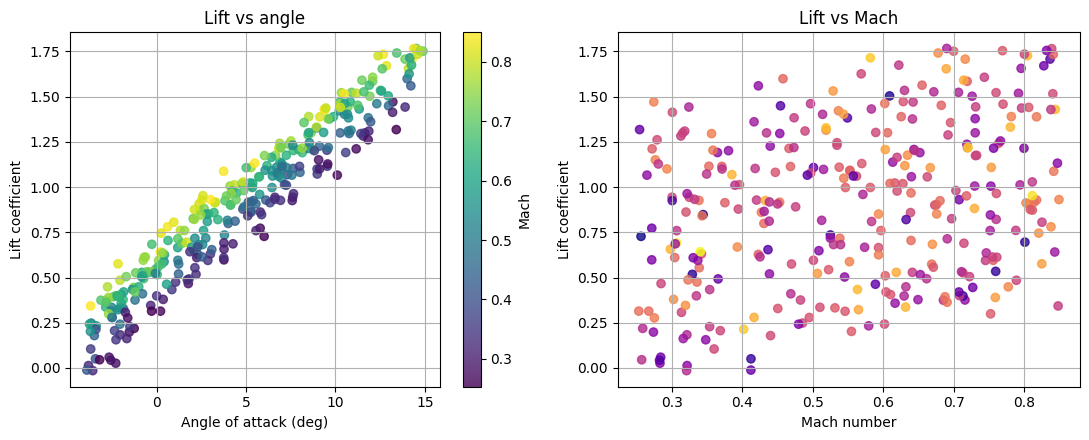

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

scatter = axes[0].scatter(
    data["angle_of_attack_deg"],
    data["lift_coefficient"],
    c=data["mach_number"],
    cmap="viridis",
    alpha=0.8,
)
axes[0].set_xlabel("Angle of attack (deg)")
axes[0].set_ylabel("Lift coefficient")
axes[0].set_title("Lift vs angle")
fig.colorbar(scatter, ax=axes[0], label="Mach")

axes[1].scatter(
    data["mach_number"],
    data["lift_coefficient"],
    c=data["temperature_k"],
    cmap="plasma",
    alpha=0.8,
)
axes[1].set_xlabel("Mach number")
axes[1].set_ylabel("Lift coefficient")
axes[1].set_title("Lift vs Mach")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "data_relationships.png", dpi=160)
plt.show()

## 2. Modeling

The random forest is used as a practical reference model. The Gaussian process is used because it returns both a mean prediction and a predictive standard deviation.

In [4]:
features = [
    "angle_of_attack_deg",
    "mach_number",
    "temperature_k",
    "geometry_factor",
]
target = "lift_coefficient"

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

baseline_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)

kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
    length_scale=np.ones(len(features)),
    length_scale_bounds=(0.1, 10.0),
    nu=1.5,
) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 0.2))

gpr_model = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=1,
        random_state=RANDOM_STATE,
    ),
)

baseline_model.fit(X_train, y_train)
gpr_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
gpr_pred, gpr_std = gpr_model.predict(X_test, return_std=True)

## 3. Evaluation

The main metrics compare point predictions. For the Gaussian process, the coverage checks how often the observed value falls inside the approximate 95 percent interval.

In [5]:
def regression_metrics(model_name, y_true, y_pred, y_std=None):
    row = {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "coverage_95": np.nan,
    }

    if y_std is not None:
        lower = y_pred - 1.96 * y_std
        upper = y_pred + 1.96 * y_std
        row["coverage_95"] = np.mean((y_true >= lower) & (y_true <= upper))

    return row


metrics_summary = pd.DataFrame(
    [
        regression_metrics("RandomForestRegressor", y_test, baseline_pred),
        regression_metrics("GaussianProcessRegressor", y_test, gpr_pred, gpr_std),
    ]
)

metrics_path = OUTPUT_DIR / "metrics_summary.csv"
metrics_summary.to_csv(metrics_path, index=False)
display(metrics_summary.round(4))
print(f"Saved metrics to: {metrics_path}")

,model,rmse,mae,r2,coverage_95
0,RandomForestRegressor,0.0555,0.0419,0.9806,NaN
1,GaussianProcessRegressor,0.0227,0.0187,0.9968,1.0


Saved metrics to: C:\00_VSC_Projects\Savoir_Coder\Alternance\uncertainty_quantification_scientific_ml\outputs\metrics_summary.csv


## 4. Visualizations

The plots compare predicted and observed values, residuals, uncertainty intervals and uncertainty along a controlled angle-of-attack sweep.

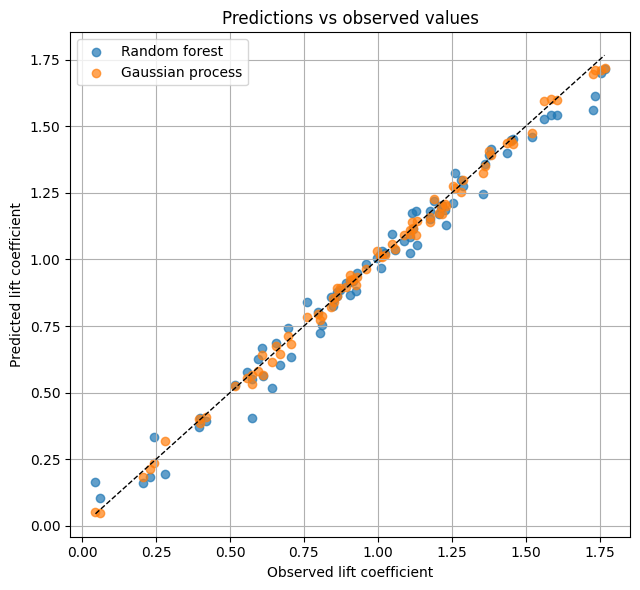

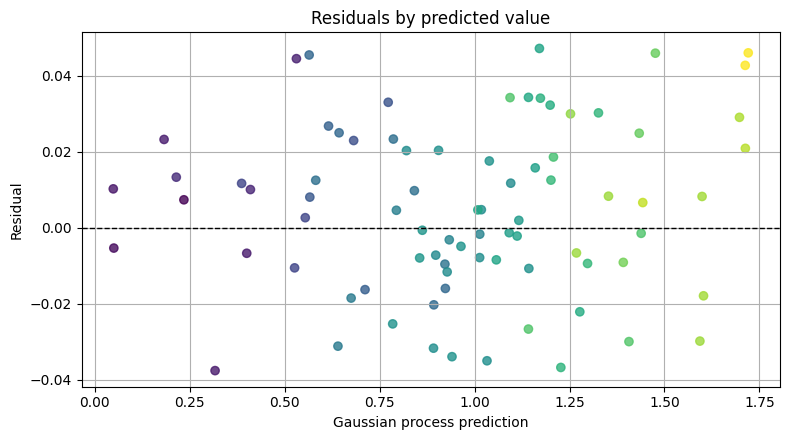

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, baseline_pred, alpha=0.7, label="Random forest")
ax.scatter(y_test, gpr_pred, alpha=0.7, label="Gaussian process")
limits = [min(y_test.min(), baseline_pred.min(), gpr_pred.min()), max(y_test.max(), baseline_pred.max(), gpr_pred.max())]
ax.plot(limits, limits, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Observed lift coefficient")
ax.set_ylabel("Predicted lift coefficient")
ax.set_title("Predictions vs observed values")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "predictions_vs_observed.png", dpi=160)
plt.show()

residuals = y_test.to_numpy() - gpr_pred

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(gpr_pred, residuals, c=X_test["angle_of_attack_deg"], cmap="viridis", alpha=0.8)
ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Gaussian process prediction")
ax.set_ylabel("Residual")
ax.set_title("Residuals by predicted value")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gpr_residuals.png", dpi=160)
plt.show()

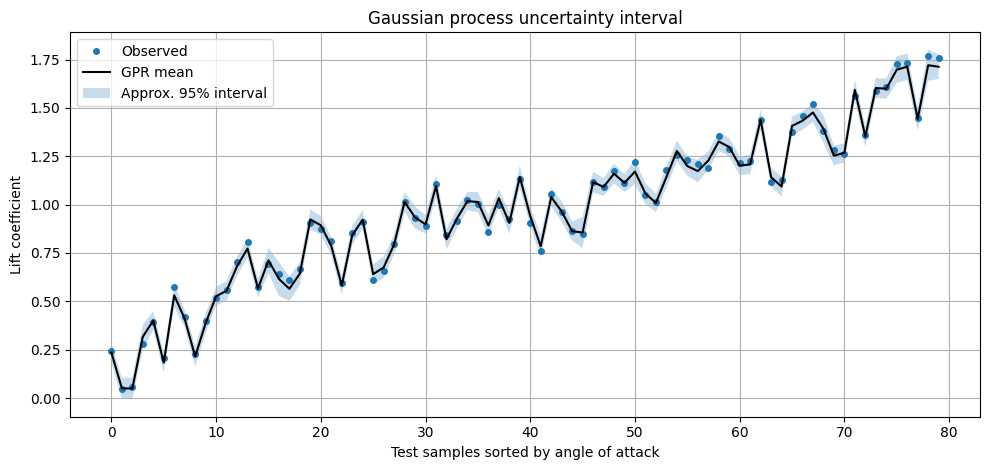

In [7]:
ordered = np.argsort(X_test["angle_of_attack_deg"].to_numpy())
x_ordered = np.arange(len(y_test))
y_ordered = y_test.to_numpy()[ordered]
pred_ordered = gpr_pred[ordered]
std_ordered = gpr_std[ordered]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(x_ordered, y_ordered, marker="o", linewidth=0, markersize=4, label="Observed")
ax.plot(x_ordered, pred_ordered, color="black", linewidth=1.5, label="GPR mean")
ax.fill_between(
    x_ordered,
    pred_ordered - 1.96 * std_ordered,
    pred_ordered + 1.96 * std_ordered,
    alpha=0.25,
    label="Approx. 95% interval",
)
ax.set_xlabel("Test samples sorted by angle of attack")
ax.set_ylabel("Lift coefficient")
ax.set_title("Gaussian process uncertainty interval")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gpr_uncertainty_interval.png", dpi=160)
plt.show()

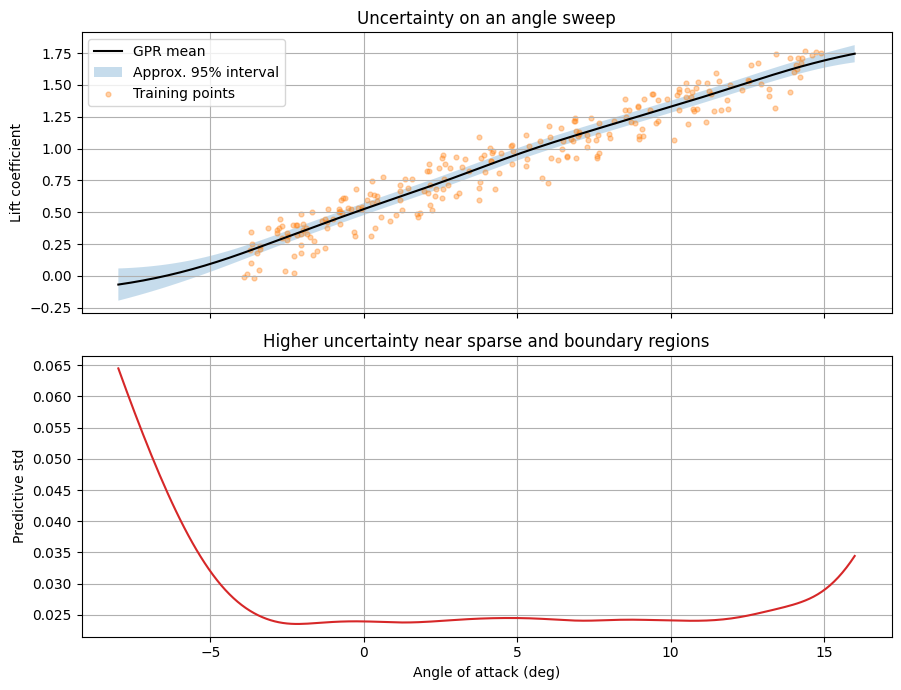

In [8]:
angle_grid = np.linspace(-8.0, 16.0, 180)
grid = pd.DataFrame(
    {
        "angle_of_attack_deg": angle_grid,
        "mach_number": 0.55,
        "temperature_k": 288.0,
        "geometry_factor": 1.0,
    }
)

grid_pred, grid_std = gpr_model.predict(grid, return_std=True)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(angle_grid, grid_pred, color="black", label="GPR mean")
axes[0].fill_between(
    angle_grid,
    grid_pred - 1.96 * grid_std,
    grid_pred + 1.96 * grid_std,
    alpha=0.25,
    label="Approx. 95% interval",
)
axes[0].scatter(
    X_train["angle_of_attack_deg"],
    y_train,
    s=12,
    alpha=0.35,
    label="Training points",
)
axes[0].set_ylabel("Lift coefficient")
axes[0].set_title("Uncertainty on an angle sweep")
axes[0].legend(loc="best")

axes[1].plot(angle_grid, grid_std, color="tab:red")
axes[1].set_xlabel("Angle of attack (deg)")
axes[1].set_ylabel("Predictive std")
axes[1].set_title("Higher uncertainty near sparse and boundary regions")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "uncertainty_by_angle.png", dpi=160)
plt.show()

## 5. Business Interpretation

The model is most reliable inside the dense part of the training domain, where the angle of attack and operating conditions are well represented. The uncertainty increases near the boundaries and in sparser regions, especially outside the main angle range. This is useful in an industrial workflow because it separates routine predictions from cases that need a simulation rerun, a physical review or additional data. A point prediction without uncertainty can look precise even when it is extrapolating.

## 6. Limits

The dataset is simulated and the aerodynamic law is simplified. The model has not been validated against real measurements or high-fidelity simulation outputs. The Gaussian process uncertainty is model-dependent and should not be treated as a certified safety margin. A real industrial use case would require domain validation, data quality checks and controlled extrapolation.

## 7. Conclusion

This notebook shows a compact Scientific ML pipeline: simulate physical data, train surrogate models, evaluate prediction error and estimate uncertainty. The Gaussian process does not only return a predicted lift coefficient; it also gives a useful signal about confidence. This helps prioritize where additional simulation or expert validation is needed.